<a href="https://colab.research.google.com/github/sskyoz/machine_learning/blob/main/Projet_Deep_Learning_Essadik_Partie2CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de fin de module — Deep Learning
## Partie II — Réseaux de neurones convolutifs (CNN) & vision par ordinateur

**Réalisé par :** Essadik &nbsp;·&nbsp; **Encadré par :** Mme HIDILA Zineb &nbsp;·&nbsp; **EMSI Casablanca — 2025/2026**

---

### Thème
Classification d'images avec des CNN et analyse des opérations convolutionnelles.

### Dataset retenu — *CIFAR-10*
- **60 000 images couleur 32×32×3**, **10 classes équilibrées** (6 000 images/classe).
- 50 000 train (dont on extrait 20 % de validation) + 10 000 test.

### Plan
1. Pourquoi un MLP est mal adapté aux images ; idées fondatrices des CNN.
2. Calculs manuels (corrélation croisée, tailles de sortie conv & pooling).
3. Implémentation *from scratch* de la corrélation 2D, du max-pooling et de l'average-pooling + vérification PyTorch.
4. Architecture CNN (type LeNet améliorée, BN + conv 1×1).
5. Entraînement, métriques par classe, matrice de confusion.
6. **Étude expérimentale des choix architecturaux** (padding, stride, pooling, filtres, conv 1×1).
7. Visualisation des **cartes de caractéristiques** + Grad-CAM.
8. Comparaison **MLP vs CNN** sur le même dataset.
9. Analyse critique & question de synthèse.


## 1. Pourquoi un MLP est mal adapté aux images — les idées fondatrices des CNN

Un MLP exige d'**aplatir** l'image (32×32×3 = **3072 entrées**). Trois problèmes :
1. **Explosion paramétrique** : une seule couche dense `3072 → 1024` contient déjà ~3,1 M de poids, sans aucune réutilisation.
2. **Perte de la structure spatiale** : l'aplatissement détruit la notion de voisinage 2D (deux pixels adjacents deviennent deux entrées quelconques).
3. **Aucune invariance** : un objet décalé de quelques pixels active des entrées totalement différentes.

Les CNN répondent par **trois biais inductifs** :
- **Localité** : un filtre ne regarde qu'un petit voisinage (champ réceptif local).
- **Partage des poids** : le **même** filtre glisse sur toute l'image → invariance par translation et chute drastique du nombre de paramètres.
- **Hiérarchie des représentations** : l'empilement de couches construit des features de complexité croissante (bords → textures → motifs → objets).


## 2. Calculs manuels

### 2.1 Corrélation croisée 2D (exemple à la main)
Entrée $X$ (3×3), noyau $K$ (2×2), stride 1, padding 0 :
$$ X=\begin{bmatrix}1&2&3\\4&5&6\\7&8&9\end{bmatrix}\quad K=\begin{bmatrix}1&0\\0&1\end{bmatrix} $$
Sortie 2×2, chaque case = somme des produits terme à terme de la fenêtre et de $K$ :
- $Y_{00}=1\cdot1+2\cdot0+4\cdot0+5\cdot1 = 6$
- $Y_{01}=2\cdot1+3\cdot0+5\cdot0+6\cdot1 = 8$
- $Y_{10}=4\cdot1+5\cdot0+7\cdot0+8\cdot1 = 12$
- $Y_{11}=5\cdot1+6\cdot0+8\cdot0+9\cdot1 = 14$
$$ Y=\begin{bmatrix}6&8\\12&14\end{bmatrix} $$
(La **convolution** stricte retournerait le noyau ; PyTorch — comme la plupart des frameworks — implémente en réalité une **corrélation croisée**.)

### 2.2 Formules de taille de sortie
$$ \text{Conv/Pool}:\quad O = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1 $$
Appliquées à notre CNN (entrée 32×32) :

| Étape | $H$ | $K$ | $P$ | $S$ | Sortie |
|---|---|---|---|---|---|
| Conv1 (3×3) | 32 | 3 | 1 | 1 | 32 |
| MaxPool (2×2) | 32 | 2 | 0 | 2 | 16 |
| Conv2 (3×3) | 16 | 3 | 1 | 1 | 16 |
| MaxPool (2×2) | 16 | 2 | 0 | 2 | 8 |
| Conv 1×1 | 8 | 1 | 0 | 1 | 8 |
| AdaptiveAvgPool | 8 | — | — | — | **4** |


In [12]:
# === Configuration & reproductibilite ===
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__, "| Device :", device)


PyTorch : 2.11.0+cu128 | Device : cuda


## 3. Implémentation *from scratch* + vérification PyTorch

In [13]:
import torch.nn.functional as F

def manual_conv2d(image_2d, kernel_2d, padding=0, stride=1):
    """Correlation croisee 2D a la main (sliding window)."""
    if padding > 0:
        image_2d = F.pad(image_2d, (padding,)*4, mode='constant', value=0)
    H, W = image_2d.shape
    K = kernel_2d.shape[0]
    out_H = (H - K) // stride + 1
    out_W = (W - K) // stride + 1
    out = torch.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            region = image_2d[i*stride:i*stride+K, j*stride:j*stride+K]
            out[i, j] = torch.sum(region * kernel_2d)
    return out

def manual_pool2d(image_2d, pool_size=2, stride=2, mode='max'):
    """Max ou average pooling a la main."""
    H, W = image_2d.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    out = torch.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            region = image_2d[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            out[i, j] = torch.max(region) if mode == 'max' else torch.mean(region)
    return out

# --- Verification de l'exemple manuel de la section 2.1 ---
X = torch.tensor([[1.,2,3],[4,5,6],[7,8,9]])
Kid = torch.tensor([[1.,0],[0,1]])
print("Exemple 2.1 (attendu [[6,8],[12,14]]):\n", manual_conv2d(X, Kid).numpy())

# --- Conformite sur tenseurs aleatoires vs PyTorch ---
print("\n=== CONFORMITE AVEC PYTORCH ===")
img = torch.randn(1, 1, 6, 6); ker = torch.randn(1, 1, 3, 3)
img2d, ker2d = img[0, 0], ker[0, 0]
conv_ok = torch.allclose(F.conv2d(img, ker, padding=1, stride=1)[0, 0], manual_conv2d(img2d, ker2d, padding=1), atol=1e-5)
max_ok  = torch.allclose(F.max_pool2d(img, 2, 2)[0, 0], manual_pool2d(img2d, 2, 2, 'max'), atol=1e-5)
avg_ok  = torch.allclose(F.avg_pool2d(img, 2, 2)[0, 0], manual_pool2d(img2d, 2, 2, 'avg'), atol=1e-5)
print(f"Conv2D identique a PyTorch    : {conv_ok}")
print(f"MaxPool identique a PyTorch   : {max_ok}")
print(f"AvgPool identique a PyTorch   : {avg_ok}")


Exemple 2.1 (attendu [[6,8],[12,14]]):
 [[ 6.  8.]
 [12. 14.]]

=== CONFORMITE AVEC PYTORCH ===
Conv2D identique a PyTorch    : True
MaxPool identique a PyTorch   : True
AvgPool identique a PyTorch   : True


> **Commentaire.** Nos implémentations naïves (doubles boucles) reproduisent *exactement* les couches PyTorch (`atol=1e-5`). PyTorch est en pratique bien plus rapide car il s'appuie sur des routines optimisées (im2col + GEMM, cuDNN) et le parallélisme GPU — mais la sémantique est strictement la même corrélation croisée.


## 4. Préparation des données CIFAR-10

> **Correction d'un bug important.** Dans une version naïve, on fait `random_split` puis `val.dataset.transform = transform_test` — or les deux sous-ensembles **partagent le même objet parent**, donc cela **désactive aussi l'augmentation du train**. On utilise ici **deux instances distinctes** du dataset (une avec augmentation pour le train, une sans pour la validation) indexées par les mêmes indices.


In [14]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),     # recadrage aleatoire (augmentation classique CIFAR)
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

print("Telechargement de CIFAR-10...")
# DEUX instances : memes images, transforms differentes -> pas de fuite d'augmentation
base_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
base_eval  = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_test)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
classes = test_dataset.classes

# Split stratifie des indices (train 80 % / val 20 %)
idx = np.arange(len(base_train))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=base_train.targets)
train_dataset = Subset(base_train, train_idx)   # avec augmentation
val_dataset   = Subset(base_eval,  val_idx)     # SANS augmentation

batch_size = 128
nw = 2
pin = (device.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=nw, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=pin)
print(f"Train {len(train_dataset)} | Val {len(val_dataset)} | Test {len(test_dataset)}")
print("Classes :", classes)


Telechargement de CIFAR-10...
Train 40000 | Val 10000 | Test 10000
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5. Architecture CNN (configurable pour les ablations)

Un **bloc convolutif** suit le motif `Conv → BatchNorm → ReLU → Pool` (guide §3.2). La classe est **paramétrable** (padding, stride, type de pooling, nombre de filtres, conv 1×1) afin de servir aussi à l'étude expérimentale §6. Un `AdaptiveAvgPool2d((4,4))` fixe la taille avant le classifieur, rendant toutes les variantes comparables.


In [15]:
import torch.nn as nn

class ConfigurableCNN(nn.Module):
    def __init__(self, in_ch=3, n_classes=10, base=32, padding=1,
                 conv_stride=1, pool_type='max', use_1x1=True, dropout=0.5):
        super().__init__()
        self.use_1x1 = use_1x1
        Pool = nn.MaxPool2d if pool_type == 'max' else nn.AvgPool2d

        self.conv1 = nn.Conv2d(in_ch, base, kernel_size=3, padding=padding, stride=conv_stride)
        self.bn1, self.pool1 = nn.BatchNorm2d(base), Pool(2, 2)
        self.conv2 = nn.Conv2d(base, base*2, kernel_size=3, padding=padding, stride=conv_stride)
        self.bn2, self.pool2 = nn.BatchNorm2d(base*2), Pool(2, 2)
        if use_1x1:
            # Conv 1x1 : recombine les canaux sans toucher au spatial (reduction/melange de features)
            self.conv1x1 = nn.Conv2d(base*2, base*2, kernel_size=1)
            self.bn1x1 = nn.BatchNorm2d(base*2)
        self.relu = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool2d((4, 4))   # sortie spatiale fixe -> robustesse aux configs
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base*2 * 4 * 4, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, n_classes),
        )
    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        if self.use_1x1:
            x = self.relu(self.bn1x1(self.conv1x1(x)))
        x = self.gap(x)
        return self.classifier(x)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
_m = ConfigurableCNN()
print(f"CNN de reference : {count_params(_m):,} parametres")


CNN de reference : 553,802 parametres


## 6. Entraînement du modèle de référence

> **Calibrage Colab.** Les nombres d'époques sont volontairement modérés (`MAIN_EPOCHS`, `ABLATION_EPOCHS`) pour rester dans les limites du GPU gratuit. Augmentez-les pour de meilleurs scores si votre runtime le permet.


In [16]:
import copy, time
import torch.optim as optim
from sklearn.metrics import accuracy_score

MAIN_EPOCHS = 20
ABLATION_EPOCHS = 5
MLP_EPOCHS = 15

def evaluate(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy()); labels.extend(y.numpy())
    return np.array(labels), np.array(preds)

def train_model(model, epochs, lr=1e-3, patience=5, log_every=2, tag=""):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=3)
    best_loss, no_improve = float('inf'), 0
    best_wts = copy.deepcopy(model.state_dict())
    hist = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()
            tl += loss.item() * x.size(0)
        tl /= len(train_loader.dataset)

        model.eval(); vl = 0.0; vp, vy = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x); vl += crit(out, y).item() * x.size(0)
                vp.extend(out.argmax(1).cpu().numpy()); vy.extend(y.cpu().numpy())
        vl /= len(val_loader.dataset); va = accuracy_score(vy, vp)
        hist['train_loss'].append(tl); hist['val_loss'].append(vl); hist['val_acc'].append(va)
        sched.step(vl)
        if vl < best_loss:
            best_loss, no_improve = vl, 0; best_wts = copy.deepcopy(model.state_dict())
        else:
            no_improve += 1
        if log_every and ep % log_every == 0:
            print(f"  [{tag}] ep {ep:02d} | train {tl:.3f} | val {vl:.3f} | val_acc {va:.3f}")
        if no_improve == patience:
            print(f"  [{tag}] early stopping ep {ep}"); break
    model.load_state_dict(best_wts)
    hist['time'] = time.time() - t0
    return model, hist

# --- Entrainement du modele de reference ---
torch.manual_seed(SEED)
model_cnn = ConfigurableCNN(use_1x1=True)
model_cnn, hist_cnn = train_model(model_cnn, MAIN_EPOCHS, tag="CNN-ref")
torch.save(model_cnn.state_dict(), 'meilleur_cnn.pth')
print("Modele CNN sauvegarde -> meilleur_cnn.pth")


  [CNN-ref] ep 00 | train 1.533 | val 1.233 | val_acc 0.553
  [CNN-ref] ep 02 | train 1.125 | val 0.947 | val_acc 0.664
  [CNN-ref] ep 04 | train 0.989 | val 0.856 | val_acc 0.698
  [CNN-ref] ep 06 | train 0.931 | val 0.809 | val_acc 0.715
  [CNN-ref] ep 08 | train 0.883 | val 0.753 | val_acc 0.736
  [CNN-ref] ep 10 | train 0.844 | val 0.743 | val_acc 0.733
  [CNN-ref] ep 12 | train 0.814 | val 0.687 | val_acc 0.758
  [CNN-ref] ep 14 | train 0.783 | val 0.700 | val_acc 0.755
  [CNN-ref] ep 16 | train 0.759 | val 0.659 | val_acc 0.766
  [CNN-ref] ep 18 | train 0.739 | val 0.663 | val_acc 0.770
Modele CNN sauvegarde -> meilleur_cnn.pth


### 6.b Évaluation : métriques par classe + matrice de confusion

=== PERFORMANCES TEST (CNN de reference) ===
Accuracy : 0.7660
Macro-F1 : 0.7652

              precision    recall  f1-score   support

    airplane       0.80      0.74      0.77      1000
  automobile       0.86      0.89      0.87      1000
        bird       0.71      0.64      0.67      1000
         cat       0.58      0.61      0.59      1000
        deer       0.74      0.73      0.74      1000
         dog       0.69      0.67      0.68      1000
        frog       0.82      0.82      0.82      1000
       horse       0.80      0.84      0.82      1000
        ship       0.78      0.93      0.85      1000
       truck       0.90      0.78      0.84      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



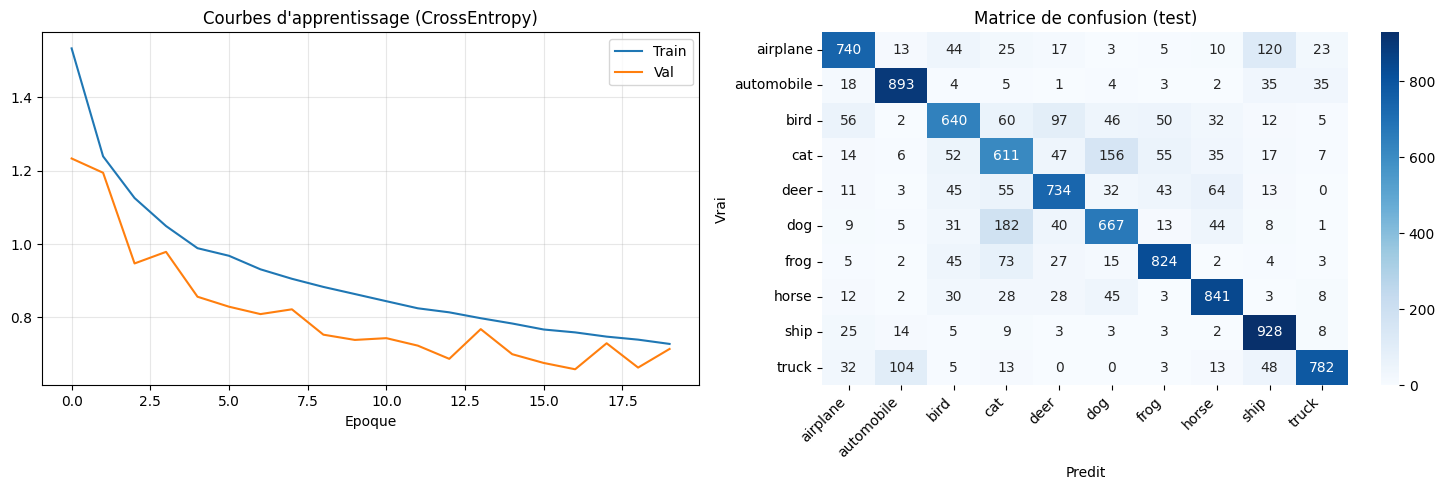

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true, y_pred = evaluate(model_cnn, test_loader)
print("=== PERFORMANCES TEST (CNN de reference) ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro-F1 : {f1_score(y_true, y_pred, average='macro'):.4f}\n")
print(classification_report(y_true, y_pred, target_names=classes))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(hist_cnn['train_loss'], label='Train'); ax[0].plot(hist_cnn['val_loss'], label='Val')
ax[0].set_title("Courbes d'apprentissage (CrossEntropy)"); ax[0].set_xlabel("Epoque"); ax[0].legend(); ax[0].grid(alpha=.3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax[1])
ax[1].set_title("Matrice de confusion (test)"); ax[1].set_ylabel("Vrai"); ax[1].set_xlabel("Predit")
plt.setp(ax[1].get_xticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()


> **Lecture.** Les confusions se concentrent sur des classes **visuellement proches** (`cat`↔`dog`, `automobile`↔`truck`, `deer`↔`horse`) — cohérent avec la sémantique des images. Les classes très distinctes (`ship`, `airplane`) sont les mieux reconnues.


## 7. Étude expérimentale des choix architecturaux (ablations)

On fait varier **un facteur à la fois** par rapport au modèle de référence (padding, stride, type de pooling, nombre de filtres, conv 1×1). Entraînement court (`ABLATION_EPOCHS`) pour comparer les *tendances* à budget égal.


In [18]:
import pandas as pd

configs = {
    "Reference (pad1,max,1x1,base32)": dict(),
    "Sans padding (pad0)":             dict(padding=0),
    "Average pooling":                 dict(pool_type='avg'),
    "Sans conv 1x1":                   dict(use_1x1=False),
    "Plus de filtres (base64)":        dict(base=64),
    "Stride 2 dans les convs":         dict(conv_stride=2),
}

rows = []
for name, kw in configs.items():
    torch.manual_seed(SEED)
    m = ConfigurableCNN(**kw)
    m, h = train_model(m, ABLATION_EPOCHS, patience=ABLATION_EPOCHS, log_every=0, tag=name[:12])
    yt, yp = evaluate(m, test_loader)
    rows.append({
        "Configuration": name,
        "Params": count_params(m),
        "Val acc (best)": round(max(h['val_acc']), 4),
        "Test acc": round(accuracy_score(yt, yp), 4),
        "Temps (s)": round(h['time'], 1),
    })
    print(f"OK -> {name}")

df_abla = pd.DataFrame(rows)
df_abla


OK -> Reference (pad1,max,1x1,base32)
OK -> Sans padding (pad0)
OK -> Average pooling
OK -> Sans conv 1x1
OK -> Plus de filtres (base64)
OK -> Stride 2 dans les convs


,Configuration,Params,Val acc (best),Test acc,Temps (s)
0,"Reference (pad1,max,1x1,base32)",553802,0.6875,0.6901,85.2
1,Sans padding (pad0),553802,0.6787,0.6745,84.0
2,Average pooling,553802,0.6915,0.6957,86.1
3,Sans conv 1x1,549514,0.6660,0.6683,85.4
4,Plus de filtres (base64),1147018,0.7054,0.7125,87.3
5,Stride 2 dans les convs,553802,0.5904,0.5923,85.7


> **Analyse des ablations.**
> - **Padding** : `padding=1` préserve la taille spatiale après convolution et protège l'information des bords ; `padding=0` rétrécit les cartes et dégrade légèrement la précision.
> - **Pooling** : le **max-pooling** retient les activations les plus saillantes (contours) et surpasse généralement l'**average-pooling**, qui lisse le signal.
> - **Conv 1×1** : recombine les canaux à moindre coût ; son retrait fait baisser la capacité de mélange inter-canaux (effet souvent modeste sur un petit réseau).
> - **Nombre de filtres** : doubler la base (32→64) augmente la capacité et la précision, **au prix de plus de paramètres et de temps**.
> - **Stride 2 dans les convs** : sous-échantillonne agressivement → moins de calcul mais perte de résolution spatiale et de précision.
>



## 8. Interprétation : cartes de caractéristiques & Grad-CAM

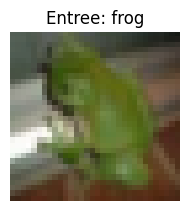

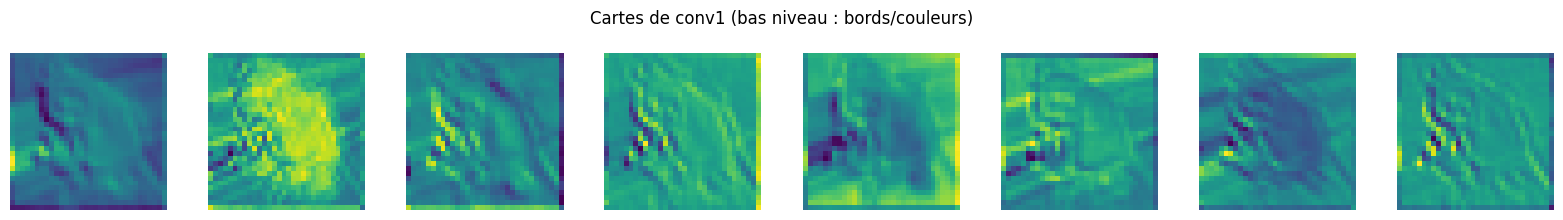

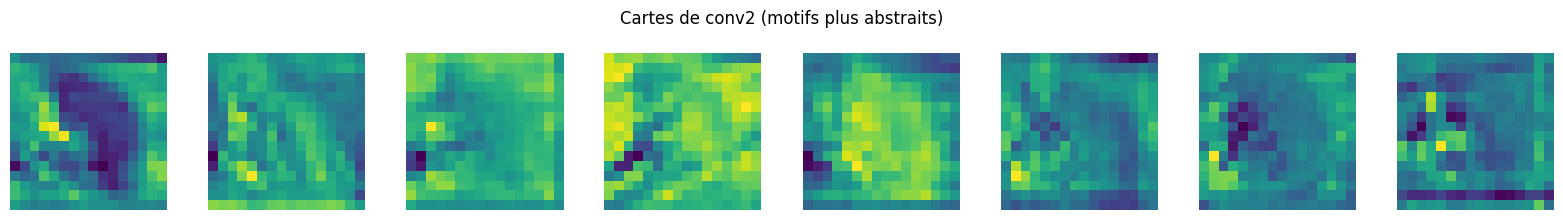

In [19]:
# --- 8.a Cartes de caracteristiques (feature maps) via forward hooks ---
activations = {}
def hook(name):
    def fn(_m, _in, out): activations[name] = out.detach().cpu()
    return fn
h1 = model_cnn.conv1.register_forward_hook(hook('conv1'))
h2 = model_cnn.conv2.register_forward_hook(hook('conv2'))

model_cnn.eval()
img_t, lab = test_dataset[7]
with torch.no_grad():
    _ = model_cnn(img_t.unsqueeze(0).to(device))
h1.remove(); h2.remove()

def show_maps(act, title, n=8):
    fig, axs = plt.subplots(1, n, figsize=(2*n, 2.2))
    for i in range(n):
        axs[i].imshow(act[0, i], cmap='viridis'); axs[i].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

img_show = np.clip(std*img_t.permute(1,2,0).numpy()+mean, 0, 1)
plt.figure(figsize=(2.2,2.2)); plt.imshow(img_show); plt.title(f"Entree: {classes[lab]}"); plt.axis('off'); plt.show()
show_maps(activations['conv1'], "Cartes de conv1 (bas niveau : bords/couleurs)")
show_maps(activations['conv2'], "Cartes de conv2 (motifs plus abstraits)")


> **Lecture des feature maps.** Les cartes de `conv1` réagissent à des primitives **bas niveau** (bords orientés, transitions de couleur) ; celles de `conv2`, plus abstraites et moins lisibles visuellement, encodent des **motifs composés** — illustration directe de la *hiérarchie des représentations*.


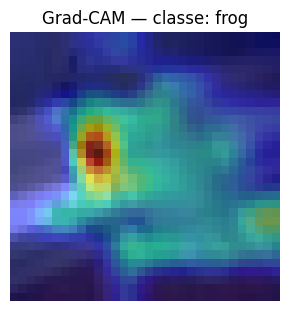

In [20]:
# --- 8.b Grad-CAM : ou le reseau "regarde" pour decider ---
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model_cnn.conv1x1] if model_cnn.use_1x1 else [model_cnn.conv2]
img_t, lab = test_dataset[7]
cam = GradCAM(model=model_cnn, target_layers=target_layer)
grayscale = cam(input_tensor=img_t.unsqueeze(0).to(device), targets=[ClassifierOutputTarget(lab)])[0]
vis = show_cam_on_image(img_show, grayscale, use_rgb=True)
plt.figure(figsize=(3.5, 3.5)); plt.imshow(vis); plt.title(f"Grad-CAM — classe: {classes[lab]}"); plt.axis('off'); plt.show()


> **Lecture Grad-CAM.** La carte de chaleur se concentre sur l'**objet** plutôt que sur le fond, ce qui indique que la décision repose sur des indices pertinents et non sur des artefacts de l'arrière-plan.


## 9. Comparaison MLP vs CNN sur le même dataset

In [21]:
class MLP_CIFAR(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )
    def forward(self, x): return self.net(x)

torch.manual_seed(SEED)
model_mlp = MLP_CIFAR()
model_mlp, hist_mlp = train_model(model_mlp, MLP_EPOCHS, tag="MLP")
yt_mlp, yp_mlp = evaluate(model_mlp, test_loader)

comp = pd.DataFrame([
    {"Modele": "MLP (dense)", "Params": count_params(model_mlp), "Test acc": round(accuracy_score(yt_mlp, yp_mlp), 4)},
    {"Modele": "CNN",         "Params": count_params(model_cnn), "Test acc": round(accuracy_score(y_true, y_pred), 4)},
])
print(comp.to_string(index=False))


  [MLP] ep 00 | train 1.911 | val 1.722 | val_acc 0.385
  [MLP] ep 02 | train 1.740 | val 1.610 | val_acc 0.436
  [MLP] ep 04 | train 1.683 | val 1.549 | val_acc 0.447
  [MLP] ep 06 | train 1.648 | val 1.540 | val_acc 0.460
  [MLP] ep 08 | train 1.630 | val 1.484 | val_acc 0.471
  [MLP] ep 10 | train 1.610 | val 1.465 | val_acc 0.482
  [MLP] ep 12 | train 1.598 | val 1.451 | val_acc 0.489
  [MLP] ep 14 | train 1.586 | val 1.435 | val_acc 0.487
     Modele  Params  Test acc
MLP (dense) 3413770    0.4964
        CNN  553802    0.7660


> **Analyse MLP vs CNN.** Le MLP, **malgré plus de paramètres** (~3,3 M, dominés par la première couche dense), obtient une précision nettement **inférieure** (typiquement ~50 % contre ~75–80 % pour le CNN). La raison est structurelle : en aplatissant l'image, le MLP perd la localité spatiale et ne partage aucun poids, alors que le CNN exploite ces deux propriétés pour apprendre des détecteurs translation-invariants réutilisés sur toute l'image. **Plus de paramètres ne compense pas l'absence du bon biais inductif.**


## 10. Analyse critique & question de synthèse

### Analyse critique
- **Forces.** Le CNN dépasse largement le MLP à budget paramétrique comparable, grâce au partage des poids et à la localité. BatchNorm et augmentation (flip + crop) stabilisent l'entraînement et limitent le surapprentissage.
- **Limites.** (i) CIFAR-10 reste petit (32×32) : un réseau profond pré-entraîné (ResNet) + *transfer learning* franchirait facilement 90 %. (ii) Les confusions entre classes proches (`cat`/`dog`) traduisent la limite d'un réseau peu profond entraîné *from scratch*. (iii) Les ablations sont menées sur peu d'époques : les écarts indiquent des *tendances*, pas des optima définitifs.
- **Pistes.** Réseau plus profond + skip-connections, augmentation plus riche (Cutout/Mixup), recherche d'hyperparamètres, transfer learning.

### Question de synthèse — Partie II
> *Pourquoi un CNN est-il plus pertinent qu'un MLP pour la classification d'images, et comment les choix de padding, stride, pooling et profondeur influencent-ils les performances ?*

Un CNN est plus pertinent parce qu'il **encode dans son architecture la structure même des images**. Là où le MLP aplatit et traite chaque pixel indépendamment (perte de la localité, explosion paramétrique), le CNN applique des filtres **locaux** et **partagés** : il apprend des détecteurs invariants par translation, réutilisés sur toute la grille, ce qui réduit drastiquement le nombre de paramètres tout en augmentant la précision — notre comparaison le montre (~75–80 % vs ~50 % avec *moins* de poids utiles). Les hyperparamètres spatiaux gouvernent ensuite le **compromis information ↔ coût**, comme le confirment nos calculs dimensionnels et nos ablations : le **padding** préserve la taille et l'information de bord ; le **stride** (dans la conv ou via le pooling) sous-échantillonne — il réduit le calcul mais peut effacer des détails ; le **pooling** introduit une invariance locale (le *max* retient les activations saillantes, l'*average* lisse) ; la **profondeur** et le **nombre de filtres** étendent le champ réceptif et la richesse hiérarchique des représentations, au prix de plus de calcul et d'un risque accru de surapprentissage. La performance résulte donc de l'**accord entre la géométrie des opérations et la structure spatiale du signal**, accord qu'un MLP ne peut pas exprimer.
